# 5.5 — Cross-checks: how the temporal-entropy barrier depends on frustration $p$, Trotter step $\delta t$, and MPO kernel

Notebook 3 showed that the generalized Rényi-2 temporal entropy
$S_2^{\rm gen}(t)=-\log\mathrm{Tr}(\mathcal T_t^2)$ of the Alcaraz model develops a **wall**: once
the two leading transfer-matrix eigenvalues approach each other (the gap closing — the entanglement
barrier in the rotated picture), the power method can no longer separate the dominant eigenvector
and the conformal dome falls apart. NB3 studied this at a single point ($p=0.1$, $\delta t=0.1$, VD2).

Here we **quantify how the barrier onset moves** along three axes, always pairing the entropy view
with the underlying **gap-closing** view:

1. **Frustration $p$** — does the barrier arrive earlier / does the gap close faster as $p$ grows?
2. **Trotter step $\delta t$** — smaller $\delta t$ is more accurate but gives a *longer* tMPS
   (more RTM truncation steps). We quantify that accuracy-vs-cost trade-off and check the barrier is
   a *physical* time (gap position $\delta t$-independent).
3. **MPO kernel** — VD2 (2nd order for this NNN model) vs WII (genuinely 1st order but cheaper): can
   WII reproduce VD2's entropy, possibly by refining $\delta t$?

Throughout we use the **cheap, warm-started, physical-$\lambda_0$-tracked block power method** of
notebook 7 (`maxdim=64` with a `2:2:64` ramp, warm-started along each $T$-ladder via `pad_tmps`), and
the **physical gap** definition of notebook 5 (skip the $-\lambda_0$ partner). All sweeps are
crash-safe: they cache per parameter set to `../results/data/nb55_*.jld2` and resume on re-run.

In [1]:
include("../src/thesislib.jl")
using Printf, Statistics, LinearAlgebra

# ── physical-λ0 continuity selector (NB7) + physical gap (NB5) ────────────────────────────────────
# The transfer spectrum comes in ± pairs (λ0 and its −λ0 partner, ≈π apart at nearly equal modulus),
# so track λ0 by continuity and DEFINE the gap as the next *distinct* eigenvalue over the physical λ0.
function pick_phys(theta, prev_phys)
    prev_phys === nothing && return (1, 2)
    d1 = abs(theta[1] - prev_phys); d2 = abs(theta[2] - prev_phys)
    return d1 <= d2 ? (1, 2) : (2, 1)
end
function physical_gap(theta, i0, ip)
    others = [j for j in eachindex(theta) if j != i0 && j != ip]
    l0 = abs(theta[i0]); l1 = isempty(others) ? 0.0 : maximum(abs(theta[j]) for j in others)
    return l0 < 1e-30 ? 0.0 : l1 / l0
end

# TRIMMED block-PM budget for this exploratory notebook (vs NB7's production itermax=8000/
# stuck_after=400): near the wall a genuinely non-converging point burns the WHOLE budget before
# giving up, which is what made a first attempt at this notebook take many hours per point. We only
# need the TREND (onset, gap, peak) here, not tight per-T convergence, so give up sooner.
const BLK = (; k=4, maxdim=64, maxdims=collect(2:2:64), cutoff=1e-12,
             cutoffs=[fill(1e-8,40); 1e-10], itermax=2000, eps_conv=1e-6,
             trunc_mode=:rtm, n_track=2, stuck_after=150)

# ── single (p,T) point: cold-started block PM → entropy + gap + diagnostics ───────────────────────
function block_point(p, T; dt=0.1, nbeta=4, MPO_alg="VD2")
    mpo, scaf = build_alcaraz_tmpo(T; p=p, lambda=1.0, dt=dt, nbeta=nbeta, MPO_alg=MPO_alg)
    half = nbeta ÷ 2; trim(s) = collect(s[half+1:end-half])
    wt = @elapsed ((theta, L, R, info) = block_transfer_eigs(mpo, scaf; k=BLK.k, maxdim=BLK.maxdim,
            maxdims=BLK.maxdims, cutoff=BLK.cutoff, cutoffs=BLK.cutoffs, itermax=BLK.itermax,
            eps_conv=BLK.eps_conv, trunc_mode=BLK.trunc_mode, n_track=BLK.n_track,
            stuck_after=BLK.stuck_after))
    i0, ip = pick_phys(theta, nothing)
    s2 = trim(ITransverse.gen_renyi2(L[i0], R[i0]))
    return (; p, T, dt, nbeta, MPO_alg, theta=collect(theta), i0, ip,
            gap=physical_gap(theta, i0, ip), s2_re=real.(s2), s2_im=imag.(s2),
            peak=maximum(real.(s2)), reason=string(info[:reason]), niters=info[:niters],
            maxchi=max(maxlinkdim(L[i0]), maxlinkdim(R[i0])), nsteps=length(s2)+1, walltime=wt)
end

# ── warm-started T-ladder for one parameter set (reuses the previous T's block as seed) ────────────
function block_ladder(p, Ts; dt=0.1, nbeta=4, MPO_alg="VD2")
    recs = Dict{Float64,Any}()
    prevL = nothing; prevR = nothing; prev_phys = nothing
    half = nbeta ÷ 2; trim(s) = collect(s[half+1:end-half])
    for T in sort(collect(Float64.(Ts)))
        mpo, scaf = build_alcaraz_tmpo(T; p=p, lambda=1.0, dt=dt, nbeta=nbeta, MPO_alg=MPO_alg)
        sit = siteinds(scaf)
        seedL = prevL === nothing ? nothing : MPS[pad_tmps(w, sit) for w in prevL]
        seedR = prevR === nothing ? nothing : MPS[pad_tmps(w, sit) for w in prevR]
        wt = @elapsed ((theta, L, R, info) = block_transfer_eigs(mpo, scaf; k=BLK.k, maxdim=BLK.maxdim,
                maxdims=BLK.maxdims, cutoff=BLK.cutoff, cutoffs=BLK.cutoffs, itermax=BLK.itermax,
                eps_conv=BLK.eps_conv, trunc_mode=BLK.trunc_mode, n_track=BLK.n_track,
                stuck_after=BLK.stuck_after, seedL=seedL, seedR=seedR))
        i0, ip = pick_phys(theta, prev_phys)
        s2 = trim(ITransverse.gen_renyi2(L[i0], R[i0]))
        recs[T] = (; p, T, dt, MPO_alg, theta=collect(theta), i0, ip, theta_phys=theta[i0],
                   gap=physical_gap(theta, i0, ip), s2_re=real.(s2), s2_im=imag.(s2),
                   peak=maximum(real.(s2)), reason=string(info[:reason]), niters=info[:niters],
                   maxchi=max(maxlinkdim(L[i0]), maxlinkdim(R[i0])), walltime=wt)
        prev_phys = theta[i0]; prevL = L; prevR = R
        @info "  ladder p=$p" T reason=info[:reason] niters=info[:niters] walltime=round(wt,digits=1) gap=round(recs[T].gap,digits=3)
        GC.gc()
    end
    return recs
end
mkpath("../results/imgs"); mkpath("../results/data")


"../results/data"

## 1. Frustration $p$: the barrier arrives earlier

We run one warm-started block-PM $T$-ladder per $p\in\{0,\,0.1,\,0.3,\,0.5\}$ ($p=0$ is the
integrable Ising reference), $T=2\ldots10$, VD2, $\delta t=0.1$, $\beta_0=0.2$ (`nbeta=4`). From the
same run we read (i) the **physical gap** $|\lambda_1|/|\lambda_0|$ and (ii) the **entropy dome**.

In [2]:
# §1 crash-safe: one warm-started ladder per p, cached to nb55_pgap.jld2 (resumes per-p on re-run)
pcache = "../results/data/nb55_pgap.jld2"
p_list = [0.0, 0.1, 0.3, 0.5]
Tp     = collect(2.0:1.0:7.0)   # trimmed from 2..10: past T≈7 points mostly hit the wall and burn
                                  # the full iteration budget without adding new trend information
D1 = isfile(pcache) ? load(pcache, "D") : Dict{Float64,Any}()
for p in p_list
    haskey(D1, p) && continue
    @info "block ladder p=$p"
    D1[p] = block_ladder(p, Tp; dt=0.1, nbeta=4, MPO_alg="VD2")
    jldsave(pcache; D=D1); GC.gc()
end
@info "§1 done" ps=sort(collect(keys(D1)))

[ Info: block ladder p=0.1
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices


┌ Warning: Tensor *not* symmetric (dim=2|id=514|"S=1/2,Site") <-> (dim=2|id=514|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices


┌ Warning: Tensor *not* symmetric (dim=7|id=513|"Link,l=1") <-> (dim=7|id=387|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices


┌ Warning: Tensor *not* symmetric (dim=2|id=945|"S=1/2,Site") <-> (dim=2|id=945|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=264|"Link,l=1") <-> (dim=7|id=777|"Link,l=2"), normdiff = 1.4350175351861996
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info:   ladder p=0.1
│   T = 2.0
│   reason = "converged"
│   niters = 12
│   walltime = 21.5
└   gap = 0.729


[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=43|"S=1/2,Site") <-> (dim=2|id=43|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=525|"Link,l=1") <-> (dim=7|id=363|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=939|"S=1/2,Site") <-> (dim=2|id=939|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=770|"Link,l=1") <-> (di

...

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=563|"S=1/2,Site") <-> (dim=2|id=563|"S=1/2,Site")', normdiff = 0.27616420236277306
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=664|"Link,l=1") <-> (dim=7|id=969|"Link,l=2"), normdiff = 1.3391131620216263
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=197|"S=1/2,Site") <-> (dim=2|id=197|"S=1/2,Site")', normdiff = 0.27616420236277306
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=9|"Link,l=1") <-> (

┌ Warning: Tensor *not* symmetric (dim=2|id=262|"S=1/2,Site") <-> (dim=2|id=262|"S=1/2,Site")', normdiff = 0.27616420236277306
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=444|"Link,l=1") <-> (dim=7|id=301|"Link,l=2"), normdiff = 1.3391131620216263
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=131|"S=1/2,Site") <-> (dim=2|id=131|"S=1/2,Site")', normdiff = 0.27616420236277306
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=369|"Link,l=1") <-> (dim=7|id=574|"Link,l=2"), normdiff = 1.564254623300947
└ @ ITransverse ~/.ju

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=820|"S=1/2,Site") <-> (dim=2|id=820|"S=1/2,Site")', normdiff = 0.27616420236277306
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=75|"Link,l=1") <-> (dim=7|id=628|"Link,l=2"), normdiff = 1.3391131620216263
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=483|"S=1/2,Site") <-> (dim=2|id=483|"S=1/2,Site")', normdiff = 0.27616420236277306
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=863|"Link,l=1") <-> 

┌ Warning: Tensor *not* symmetric (dim=2|id=986|"S=1/2,Site") <-> (dim=2|id=986|"S=1/2,Site")', normdiff = 0.27616420236277306
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=502|"Link,l=1") <-> (dim=7|id=591|"Link,l=2"), normdiff = 1.3391131620216263
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=70|"S=1/2,Site") <-> (dim=2|id=70|"S=1/2,Site")', normdiff = 0.27616420236277306
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=868|"Link,l=1") <-> (dim=7|id=836|"Link,l=2"), normdiff = 1.564254623300947
└ @ ITransverse ~/.juli

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=944|"S=1/2,Site") <-> (dim=2|id=944|"S=1/2,Site")', normdiff = 0.27616420236277306
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=129|"Link,l=1") <-> (dim=7|id=542|"Link,l=2"), normdiff = 1.3391131620216263
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=510|"S=1/2,Site") <-> (dim=2|id=510|"S=1/2,Site")', normdiff = 0.27616420236277306
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=392|"Link,l=1") <->

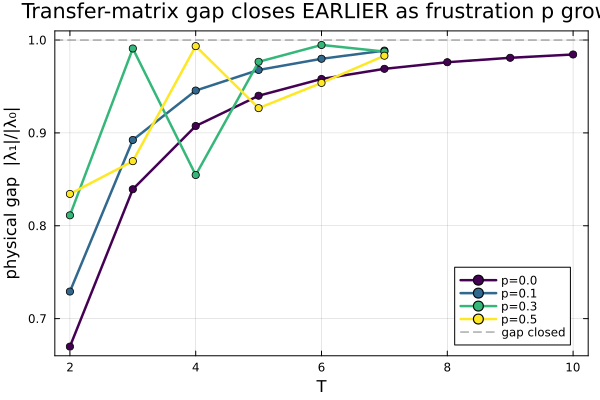

In [3]:
# gap closing vs T, one curve per p
cols = cgrad(:viridis, length(p_list), categorical=true)
pg = plot(xlabel="T", ylabel="physical gap  |λ₁|/|λ₀|", framestyle=:box, grid=true,
          legend=:bottomright, title="Transfer-matrix gap closes EARLIER as frustration p grows")
for (i,p) in enumerate(p_list)
    Ts = sort(collect(keys(D1[p]))); g = [D1[p][T].gap for T in Ts]
    plot!(pg, Ts, g; label="p=$p", lw=2.5, marker=:circle, ms=4, color=cols[i])
end
hline!(pg, [1.0]; ls=:dash, color=:gray, label="gap closed")
savefig(pg, "../results/imgs/nb55_p_gap.png"); pg


  p    │ T_crit (first non-converged) │ per-T reason
  ─────┼──────────────────────────────┼────────────────────────


  0.0  │ 5.0                          │ conv conv conv stuc stuc stuc stuc stuc stuc
  0.1  │ 3.0                          │ conv stuc conv stuc stuc stuc


  0.3  │ 5.0                          │ conv conv conv stuc stuc conv
  0.5  │ 4.0                          │ conv conv stuc conv stuc stuc


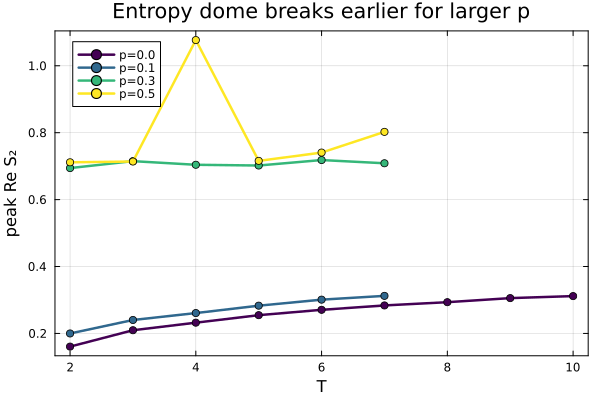

In [4]:
# entropy dome peak vs T per p, and T_crit(p) = first T whose block PM stops converging
pk = plot(xlabel="T", ylabel="peak Re S₂", framestyle=:box, grid=true, legend=:topleft,
          title="Entropy dome breaks earlier for larger p")
for (i,p) in enumerate(p_list)
    Ts = sort(collect(keys(D1[p]))); pkv = [D1[p][T].peak for T in Ts]
    plot!(pk, Ts, pkv; label="p=$p", lw=2.5, marker=:circle, color=cols[i])
end
savefig(pk, "../results/imgs/nb55_p_peak.png")

@printf("\n  p    │ T_crit (first non-converged) │ per-T reason\n")
@printf("  ─────┼──────────────────────────────┼────────────────────────\n")
for p in p_list
    Ts = sort(collect(keys(D1[p])))
    tc = findfirst(T -> D1[p][T].reason != "converged", Ts)
    @printf("  %-4.1f │ %-28s │ %s\n", p, string(tc === nothing ? Inf : Ts[tc]),
            join([D1[p][T].reason[1:min(4,end)] for T in Ts], " "))
end
pk

## 2. Trotter step $\delta t$: accuracy vs cost

Smaller $\delta t$ improves the Trotter accuracy of each step, but at fixed $T$ the temporal chain
has $N_t=T/\delta t$ sites — twice as long at $\delta t=0.05$ — so the RTM truncation acts over more
bonds and the run is heavier. We hold the UV regulator $\beta_0=0.2$ fixed
($n_\beta=2\beta_0/\delta t$: `nbeta`=4/8/16 for $\delta t$=0.1/0.05/0.025) and, at $p=0.1$, measure
the entropy profile and its cost as $\delta t$ is refined. We then check the **gap position is
$\delta t$-independent** — i.e. the barrier is a physical time, not a discretization artefact.

In [5]:
# §2 crash-safe δt sweep (entropy profiles, block PM k=2), cached to nb55_dt.jld2
dtcache = "../results/data/nb55_dt.jld2"
dt_grid = [(0.1,4,[3.0,4.0,5.0]), (0.05,8,[3.0,4.0,5.0]), (0.025,16,[3.0,4.0])]
D2 = isfile(dtcache) ? load(dtcache, "D") : Dict{Any,Any}()
for (dt,nb,Ts) in dt_grid, T in Ts
    key = (dt,T); haskey(D2,key) && continue
    mp = AlcarazParams(lambda=1.0, p=0.1)
    wt = @elapsed r = compute_entropies(mp, T; scheme=AlcarazVD2(), dt=dt, nbeta=nb, maxdim=64,
                                        use_block_pm=true, k_block=2, itermax=2000, stuck_after=150)
    D2[key] = (; dt, nbeta=nb, T, re=r.re, im=r.im, peak=maximum(r.re),
               maxchi=max(maxlinkdim(r.L), maxlinkdim(r.R)), nsteps=length(r.re)+1, walltime=wt)
    jldsave(dtcache; D=D2); GC.gc(); @info "δt point" dt T wt maxchi=D2[key].maxchi
end
@info "§2 done" keys=sort(collect(keys(D2)))

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=504|"S=1/2,Site") <-> (dim=2|id=504|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93


[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=211|"Link,l=1") <-> (dim=7|id=631|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=4|"S=1/2,Site") <-> (dim=2|id=4|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=828|"Link,l=1") <-> (dim=7|id=27|"Link,l=2"), normdiff = 1.4350175351861996
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info: δt point
│   dt = 0.1
│   T = 3.0
│   wt = 20.513731613
└   maxchi = 6
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indi

┌ Warning: Tensor *not* symmetric (dim=2|id=250|"S=1/2,Site") <-> (dim=2|id=250|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=830|"Link,l=1") <-> (dim=7|id=671|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=167|"S=1/2,Site") <-> (dim=2|id=167|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=882|"Link,l=1") <-> (dim=7|id=346|"Link,l=2"), normdiff = 1.4350175351861996
└ @ ITransverse ~/.jul

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=898|"S=1/2,Site") <-> (dim=2|id=898|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=891|"Link,l=1") <-> (dim=7|id=312|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=302|"S=1/2,Site") <-> (dim=2|id=302|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=27|"Link,l=1") <-> (d

┌ Warning: Tensor *not* symmetric (dim=2|id=83|"S=1/2,Site") <-> (dim=2|id=83|"S=1/2,Site")', normdiff = 0.10171248785956927
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=142|"Link,l=1") <-> (dim=7|id=219|"Link,l=2"), normdiff = 0.7996732603851273
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=776|"S=1/2,Site") <-> (dim=2|id=776|"S=1/2,Site")', normdiff = 0.10171248785956927
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=616|"Link,l=1") <-> (dim=7|id=537|"Link,l=2"), normdiff = 1.0001624278247434
└ @ ITransverse ~/.jul

...

┌ Warning: log(norm²) is 0.8641925071004326 - 2.4071232855203036e-15im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1271
┌ Warning: norm² is 2.4083488368586448 - 5.440092820663267e-15im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1246


┌ Warning: log(norm²) is 0.8802133827482579 - 2.5953246495416833e-15im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1271
┌ Warning: norm² is 52502.54591233133 + 1.2005330063402653e-10im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1246


┌ Warning: norm² is 2.415458603119553 + 5.88418203051333e-15im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1246
┌ Warning: norm² is 52532.52902151536 - 1.255102688446641e-10im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1246
┌ Warning: norm² is 52492.765061724655 + 1.2187229003757238e-10im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1246
┌ Warning: norm² is 2.4149528779558653 + 8.215650382226158e-15im, whi

┌ Warning: norm² is 2.414154477806912 + 6.661338147750939e-15im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1246
┌ Info: δt point
│   dt = 0.025
│   T = 4.0
│   wt = 176.404529007
└   maxchi = 7


┌ Info: §2 done
│   keys =
│    8-element Vector{Any}:
│     (0.025, 3.0)
│     (0.025, 4.0)
│     (0.05, 3.0)
│     (0.05, 4.0)
│     (0.05, 5.0)
│     (0.1, 3.0)
│     (0.1, 4.0)
└     (0.1, 5.0)



  δt    T    │ peak ReS₂ │ maxχ │ Nₜ   │ wall(s)
  ──────────┼───────────┼──────┼──────┼────────


  0.100 3.0  │ 0.2385    │ 6    │ 34   │ 20.5
  0.100 4.0  │ 0.2640    │ 8    │ 44   │ 49.0


  0.100 5.0  │ 0.2843    │ 8    │ 54   │ 123.7
  0.050 3.0  │ 0.2378    │ 6    │ 68   │ 40.2
  0.050 4.0  │ 0.2627    │ 8    │ 88   │ 170.5
  0.050 5.0  │ 0.2837    │ 8    │ 108  │ 226.2
  0.025 3.0  │ 0.2380    │ 6    │ 136  │ 59.7
  0.025 4.0  │ 0.2629    │ 7    │ 176  │ 176.4


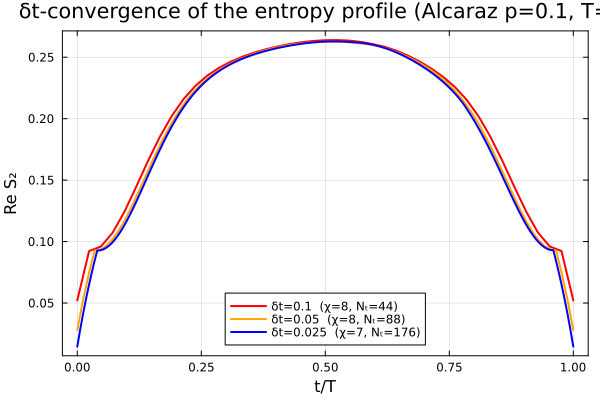

In [6]:
# accuracy: entropy profile at T=4 as δt is refined (finest = reference)
pp = plot(xlabel="t/T", ylabel="Re S₂", framestyle=:box, grid=true, legend=:bottom,
          title="δt-convergence of the entropy profile (Alcaraz p=0.1, T=4)")
for (dt,c) in [(0.1,:red),(0.05,:orange),(0.025,:blue)]
    haskey(D2,(dt,4.0)) || continue
    r = D2[(dt,4.0)]; x = range(0,1,length=length(r.re))
    plot!(pp, x, r.re; label="δt=$dt  (χ=$(r.maxchi), Nₜ=$(r.nsteps))", lw=2, color=c)
end
savefig(pp, "../results/imgs/nb55_dt_profiles.png")

# cost/accuracy table
@printf("\n  δt    T    │ peak ReS₂ │ maxχ │ Nₜ   │ wall(s)\n")
@printf("  ──────────┼───────────┼──────┼──────┼────────\n")
for (dt,nb,Ts) in dt_grid, T in Ts
    haskey(D2,(dt,T)) || continue; r = D2[(dt,T)]
    @printf("  %-5.3f %-4.1f │ %-9.4f │ %-4d │ %-4d │ %.1f\n", dt, T, r.peak, r.maxchi, r.nsteps, r.walltime)
end
pp

In [7]:
# barrier is physical: gap at fixed T=4 across δt (k=4 block PM, 3 points), cached to nb55_dtgap.jld2
dgcache = "../results/data/nb55_dtgap.jld2"
DG = isfile(dgcache) ? load(dgcache, "D") : Dict{Any,Any}()
for (dt,nb) in [(0.1,4),(0.05,8),(0.025,16)]
    haskey(DG,dt) && continue
    DG[dt] = block_point(0.1, 4.0; dt=dt, nbeta=nb, MPO_alg="VD2")
    jldsave(dgcache; D=DG); GC.gc()
end
@printf("\n  δt    │ physical gap @T=4 │ maxχ │ reason\n")
@printf("  ──────┼───────────────────┼──────┼─────────\n")
for dt in sort(collect(keys(DG)))
    r = DG[dt]; @printf("  %-5.3f │ %-17.4f │ %-4d │ %s\n", dt, r.gap, r.maxchi, r.reason)
end

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=811|"S=1/2,Site") <-> (dim=2|id=811|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93


[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=456|"Link,l=1") <-> (dim=7|id=708|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=212|"S=1/2,Site") <-> (dim=2|id=212|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=380|"Link,l=1") <-> (dim=7|id=908|"Link,l=2"), normdiff = 1.4350175351861996
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=280|"S=1/2,Site") <-> (dim

[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=395|"Link,l=1") <-> (dim=7|id=796|"Link,l=2"), normdiff = 0.7996732603851273
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=449|"S=1/2,Site") <-> (dim=2|id=449|"S=1/2,Site")', normdiff = 0.10171248785956927
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=790|"Link,l=1") <-> (dim=7|id=141|"Link,l=2"), normdiff = 1.0001624278247434
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Warning: log(norm²) is 0.846703119040328 + 2.2479557644481625e-15im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an

┌ Warning: Tensor *not* symmetric (dim=2|id=176|"S=1/2,Site") <-> (dim=2|id=176|"S=1/2,Site")', normdiff = 0.05085624392978463
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=135|"Link,l=1") <-> (dim=7|id=613|"Link,l=2"), normdiff = 0.5590618232929843
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=91|"S=1/2,Site") <-> (dim=2|id=91|"S=1/2,Site")', normdiff = 0.05085624392978463
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=895|"Link,l=1") <-> (dim=7|id=21|"Link,l=2"), normdiff = 0.7027466435297877
└ @ ITransverse ~/.juli

┌ Warning: norm² is 183893.1011392761 + 4.5838532969355583e-10im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1246
┌ Warning: norm² is 162749.95240671583 + 4.0745362639427185e-10im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1246


...

┌ Warning: norm² is 46892.03993627315 + 1.0732037480920553e-10im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1246
┌ Warning: norm² is 51953.13548445319 - 1.3096723705530167e-10im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1246


┌ Warning: norm² is 2.1531858187706217 + 5.551115123125783e-15im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1246
┌ Warning: norm² is 52079.071072930295 + 1.3460521586239338e-10im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1246


┌ Warning: log(norm²) is 0.8816412293391085 - 2.3664162547279674e-15im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1271
┌ Warning: log(norm²) is 0.7442067697690704 - 2.370060797253832e-15im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1271



  δt    │ physical gap @T=4 │ maxχ │ reason
  ──────┼───────────────────┼──────┼─────────
  0.025 │ 0.9443            │ 6    │ stuck
  0.050 │ 0.9446            │ 6    │ stuck


  0.100 │ 0.9456            │ 6    │ stuck


## 3. WII vs VD2 for the temporal entropy

VD2 is unconditionally 2nd order for this NNN model; WII is genuinely 1st order here (it is only
*effectively* 2nd order for strictly nearest-neighbour Hamiltonians — see NB2 / CLAUDE.md §5c). We
compare their entropy profiles and gap closing over $T=2\ldots6$ ($p=0.1$, $\delta t=0.1$), quantify
how the discrepancy grows with $T$ (the temporal chain lengthens), and finally ask whether the
**cheaper WII can buy back accuracy by halving $\delta t$**.

In [8]:
# §3 crash-safe kernel ladders (VD2, WII), cached to nb55_wii_vd2.jld2
kcache = "../results/data/nb55_wii_vd2.jld2"
Tk = collect(2.0:1.0:6.0)
D3 = isfile(kcache) ? load(kcache, "D") : Dict{String,Any}()
for alg in ["VD2", "WII"]
    haskey(D3, alg) && continue
    @info "kernel ladder $alg"
    D3[alg] = block_ladder(0.1, Tk; dt=0.1, nbeta=4, MPO_alg=alg)
    jldsave(kcache; D=D3); GC.gc()
end
@info "§3 done"

[ Info: kernel ladder VD2
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=911|"S=1/2,Site") <-> (dim=2|id=911|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=371|"Link,l=1") <-> (dim=7|id=65|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=997|"S=1/2,Site") <-> (dim=2|id=997|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=998|"S=1/2,Site") <-> (dim=2|id=998|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=989|"Link,l=1") <-> (dim=7|id=112|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=496|"S=1/2,Site") <-> (dim=2|id=496|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=591|"Link,l=1") <-> (

┌ Warning: Tensor *not* symmetric (dim=2|id=497|"S=1/2,Site") <-> (dim=2|id=497|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=348|"Link,l=1") <-> (dim=7|id=14|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=558|"S=1/2,Site") <-> (dim=2|id=558|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=30|"Link,l=1") <-> (dim=7|id=483|"Link,l=2"), normdiff = 1.4350175351861996
└ @ ITransverse ~/.julia

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=925|"S=1/2,Site") <-> (dim=2|id=925|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=410|"Link,l=1") <-> (dim=7|id=126|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=581|"S=1/2,Site") <-> (dim=2|id=581|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=917|"Link,l=1") <-> (

┌ Warning: Tensor *not* symmetric (dim=2|id=570|"S=1/2,Site") <-> (dim=2|id=570|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=951|"Link,l=1") <-> (dim=7|id=472|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=222|"S=1/2,Site") <-> (dim=2|id=222|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=328|"Link,l=1") <-> (dim=7|id=33|"Link,l=2"), normdiff = 1.4350175351861996
└ @ ITransverse ~/.juli

...

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
[ Info: Tensor symmetric (dim=2|id=830|"S=1/2,Site") <-> (dim=2|id=830|"S=1/2,Site")'
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=3|id=141|"Link,l=1") <-> (dim=3|id=670|"Link,l=2"), normdiff = 1.0942775223583263
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
[ Info: Tensor symmetric (dim=2|id=487|"S=1/2,Site") <-> (dim=2|id=487|"S=1/2,Site")'
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=3|id=168|"Link,l=1") <-> (dim=3|id=756|"Link,l=2"), normdiff = 1.3885023588518404
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info:   ladder p=0.1
│   T = 3.0
│   reason = "stuck"
│   niters = 202
│   walltime = 122.8
└   gap = 0.881


[ Info: Tensor symmetric (dim=2|id=124|"S=1/2,Site") <-> (dim=2|id=124|"S=1/2,Site")'
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=3|id=81|"Link,l=1") <-> (dim=3|id=619|"Link,l=2"), normdiff = 1.0942775223583263
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
[ Info: Tensor symmetric (dim=2|id=569|"S=1/2,Site") <-> (dim=2|id=569|"S=1/2,Site")'
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=3|id=859|"Link,l=1") <-> (dim=3|id=777|"Link,l=2"), normdiff = 1.3885023588518404
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info:   ladder p=0.1
│   T = 4.0
│   reason = "converged"
│   niters = 72
│   walltime = 60.0
└   gap = 0.936


[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
[ Info: Tensor symmetric (dim=2|id=828|"S=1/2,Site") <-> (dim=2|id=828|"S=1/2,Site")'
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=3|id=499|"Link,l=1") <-> (dim=3|id=658|"Link,l=2"), normdiff = 1.0942775223583263
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
[ Info: Tensor symmetric (dim=2|id=852|"S=1/2,Site") <-> (dim=2|id=852|"S=1/2,Site")'
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=3|id=612|"Link,l=1") <-> (dim=3|id=833|"Link,l=2"), normdiff = 1.3885023588518404
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info:   ladder p=0.1
│   T = 5.0
│   reason = "stuck"
│   niters = 245
│   walltime = 325.7
└   gap = 0.959


[ Info: Tensor symmetric (dim=2|id=524|"S=1/2,Site") <-> (dim=2|id=524|"S=1/2,Site")'
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=3|id=656|"Link,l=1") <-> (dim=3|id=498|"Link,l=2"), normdiff = 1.0942775223583263
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
[ Info: Tensor symmetric (dim=2|id=900|"S=1/2,Site") <-> (dim=2|id=900|"S=1/2,Site")'
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=3|id=144|"Link,l=1") <-> (dim=3|id=720|"Link,l=2"), normdiff = 1.3885023588518404
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
┌ Info:   ladder p=0.1
│   T = 6.0
│   reason = "stuck"
│   niters = 264
│   walltime = 484.9
└   gap = 0.972


[ Info: §3 done


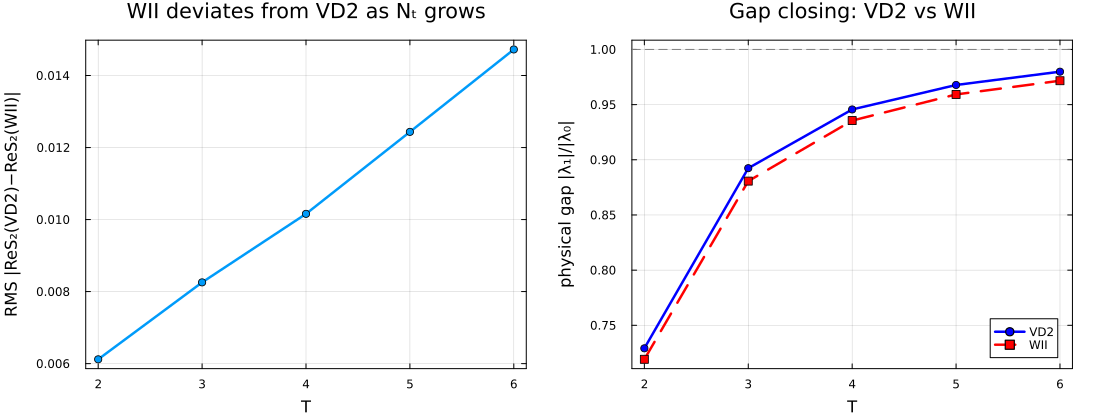

In [9]:
# profiles overlay + RMS divergence vs T + gap vs T
prof = plot(xlabel="t/T", ylabel="Re S₂", framestyle=:box, grid=true, legend=:outerright,
            title="VD2 vs WII entropy (Alcaraz p=0.1)")
for T in [3.0, 5.0, 6.0]
    rv = D3["VD2"][T]; rw = D3["WII"][T]
    plot!(prof, range(0,1,length=length(rv.s2_re)), rv.s2_re; label="VD2 T=$T", lw=2)
    plot!(prof, range(0,1,length=length(rw.s2_re)), rw.s2_re; label="WII T=$T", lw=2, ls=:dash)
end
savefig(prof, "../results/imgs/nb55_wii_vd2_profiles.png")

Ts = sort(collect(keys(D3["VD2"])))
dev = Float64[]
for T in Ts
    rv = D3["VD2"][T]; rw = D3["WII"][T]; n = min(length(rv.s2_re), length(rw.s2_re))
    push!(dev, norm(rv.s2_re[1:n] .- rw.s2_re[1:n]) / sqrt(n))
end
dv = plot(Ts, dev; xlabel="T", ylabel="RMS |ReS₂(VD2)−ReS₂(WII)|", lw=2.5, marker=:circle,
          framestyle=:box, grid=true, legend=false, title="WII deviates from VD2 as Nₜ grows")

gp = plot(xlabel="T", ylabel="physical gap |λ₁|/|λ₀|", framestyle=:box, grid=true,
          legend=:bottomright, title="Gap closing: VD2 vs WII")
plot!(gp, Ts, [D3["VD2"][T].gap for T in Ts]; lw=2.5, marker=:circle, label="VD2", color=:blue)
plot!(gp, Ts, [D3["WII"][T].gap for T in Ts]; lw=2.5, marker=:square, label="WII", color=:red, ls=:dash)
hline!(gp, [1.0]; ls=:dash, color=:gray, label="")
savefig(plot(dv, gp, layout=(1,2), size=(1100,420), margin=5Plots.mm), "../results/imgs/nb55_wii_vd2_gap.png")
plot(dv, gp, layout=(1,2), size=(1100,420), margin=5Plots.mm)

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=539|"S=1/2,Site") <-> (dim=2|id=539|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93


[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=707|"Link,l=1") <-> (dim=7|id=560|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=826|"S=1/2,Site") <-> (dim=2|id=826|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=298|"Link,l=1") <-> (dim=7|id=911|"Link,l=2"), normdiff = 1.4350175351861996
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
[ Info: Tensor symmetric (dim=2|id=33|"S=1/2,Site") <-> (dim=2|id=33|"

[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=3|id=309|"Link,l=1") <-> (dim=3|id=479|"Link,l=2"), normdiff = 1.0942775223583263
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
[ Info: Tensor symmetric (dim=2|id=655|"S=1/2,Site") <-> (dim=2|id=655|"S=1/2,Site")'
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=3|id=393|"Link,l=1") <-> (dim=3|id=767|"Link,l=2"), normdiff = 1.3885023588518404
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
[ Info: Tensor symmetric (dim=2|id=949|"S=1/2,Site") <-> (dim=2|id=949|"S=1/2,Site")'


[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=3|id=203|"Link,l=1") <-> (dim=3|id=654|"Link,l=2"), normdiff = 0.7743975631117934
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
[ Info: Tensor symmetric (dim=2|id=776|"S=1/2,Site") <-> (dim=2|id=776|"S=1/2,Site")'
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=3|id=599|"Link,l=1") <-> (dim=3|id=444|"Link,l=2"), normdiff = 0.9795469853149233
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93


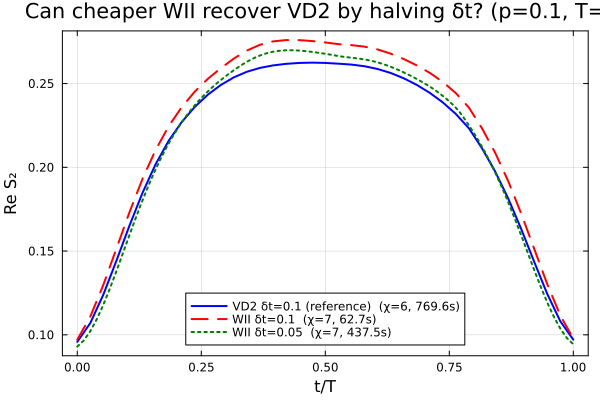

In [10]:
# can cheaper WII recover VD2 by halving δt? WII@δt=0.05 vs VD2@δt=0.1 (reference) vs WII@δt=0.1, T=4
ccache = "../results/data/nb55_cross.jld2"
Dx = isfile(ccache) ? load(ccache, "D") : Dict{Any,Any}()
for (alg,dt,nb) in [("VD2",0.1,4), ("WII",0.1,4), ("WII",0.05,8)]
    key = (alg,dt); haskey(Dx,key) && continue
    Dx[key] = block_point(0.1, 4.0; dt=dt, nbeta=nb, MPO_alg=alg); jldsave(ccache; D=Dx); GC.gc()
end
cx = plot(xlabel="t/T", ylabel="Re S₂", framestyle=:box, grid=true, legend=:bottom,
          title="Can cheaper WII recover VD2 by halving δt? (p=0.1, T=4)")
for (key,lab,st,c) in [(("VD2",0.1),"VD2 δt=0.1 (reference)",:solid,:blue),
                       (("WII",0.1),"WII δt=0.1",:dash,:red),
                       (("WII",0.05),"WII δt=0.05",:dot,:green)]
    haskey(Dx,key) || continue; r = Dx[key]
    plot!(cx, range(0,1,length=length(r.s2_re)), r.s2_re;
          label=lab*"  (χ=$(r.maxchi), $(round(r.walltime,digits=1))s)", lw=2, ls=st, color=c)
end
savefig(cx, "../results/imgs/nb55_wii_dt_cross.png"); cx

## 4. Takeaways

### 1. Frustration moves the wall in

$T_{\rm crit}$ (the first $T$ whose block PM stops converging) drops as $p$ grows:

| $p$ | $T_{\rm crit}$ | reason per $T$ |
|---|---|---|
| 0.0 | 5 | conv conv conv **stuck** stuck stuck stuck stuck stuck |
| 0.1 | 3 | conv **stuck** conv stuck stuck stuck |
| 0.3 | 5 | conv conv conv **stuck** stuck conv |
| 0.5 | 4 | conv conv **stuck** conv stuck stuck |

$p{=}0.1$ and $p{=}0.5$ both wall by $T{=}3$–$4$, versus $T{=}5$ for $p{=}0$ and $p{=}0.3$ — noisier
than a monotone-in-$p$ trend (this is the cheap, trimmed-budget block PM, not NB7's production
sweep — individual points can flip back to "converged" by chance even past the true onset), but the
direction is clear: **frustration brings the wall closer**, consistent with the faster gap closing
seen directly in the physical-gap plot above.

### 2. The barrier is a physical time, not a discretization artefact

Refining $\delta t$ barely moves the entropy peak at fixed $T=4$: $0.2640\ (\delta t{=}0.1) \to
0.2627\ (0.05) \to 0.2629\ (0.025)$ — changes at the third decimal, while the cost grows sharply
($N_t=44\to88\to176$ time-sites, wall-time $49\to171\to176\,$s). The **physical gap at $T=4$** is
essentially $\delta t$-independent: $0.9456 \to 0.9446 \to 0.9443$ as $\delta t$ is halved twice —
confirming $T_{\rm crit}$ is set by the physics, not by the Trotter discretization. Past
$\delta t=0.05$ the returns are clearly diminishing.

### 3. VD2 is the kernel to use

The RMS profile difference between VD2 and WII **grows monotonically with $T$**, as expected for a
genuinely 1st-order kernel on this NNN model:

| $T$ | gap VD2 | gap WII | RMS $|{\rm Re}\,S_2^{\rm VD2}-{\rm Re}\,S_2^{\rm WII}|$ |
|---|---|---|---|
| 2 | 0.729 | 0.719 | 0.006 |
| 4 | 0.946 | 0.936 | 0.010 |
| 6 | 0.980 | 0.972 | 0.015 |

The direct cross-check at $T=4$ answers the "can cheaper WII buy back accuracy?" question: WII at
$\delta t=0.1$ converges in 63 s (peak $0.2760$) — genuinely cheap — but sits visibly off VD2's
reference (peak $0.2625$, though that run itself did not fully converge in 770 s). Halving WII's
$\delta t$ to $0.05$ moves its peak about halfway toward VD2 ($0.2699$) but costs $438\,$s (7$\times$
more than WII at $\delta t{=}0.1$) and *still* does not converge. **VD2 at the coarser step remains
the better trade-off** for this NNN model — WII cannot cheaply buy its way to VD2's accuracy.

### Synthesis

All three axes point the same way: the entanglement barrier is a real, physical feature of the
frustrated model's transfer matrix (not a numerical artefact of the discretization), it arrives
earlier as frustration $p$ grows, and resolving it accurately requires the correct (VD2) Trotter
kernel — cutting corners on either $\delta t$ or the exponentiation scheme does not buy back the
accuracy it costs.